# Investigation 04 — Provider conservatism comparison

This notebook investigates whether providers differ not only in accuracy, but in their tendency to abstain.

Conservatism is operationalised as the tendency to predict:

- `schema_present = no`
- `main_image_schema = NONE`
- `literal_or_metaphorical = control`

Thesis use:
- Supports the model/provider comparison section.
- Distinguishes accuracy from response-style bias.
- Tests whether a provider is genuinely more accurate or simply more/less conservative.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"

EXPORT_DIR = OUTPUTS_DIR / "top4_investigations"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {line_no}: {exc}") from exc
    return pd.DataFrame(rows)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def prompt_generation(prompt_id) -> str:
    prompt_id = str(prompt_id)
    if "v2" in prompt_id or "abstention" in prompt_id:
        return "v2_abstention"
    if "v1" in prompt_id:
        return "v1"
    return "unknown"

def prompt_base(prompt_id: str) -> str:
    prompt_id = str(prompt_id)
    if "direct_schema" in prompt_id:
        return "direct_schema"
    if "structured_roles" in prompt_id:
        return "structured_roles"
    if "naive" in prompt_id:
        return "naive"
    return "unknown"

def condition_family_from_id(condition_id) -> str:
    condition_id = str(condition_id)
    if "temp_0" in condition_id:
        return "temp_0"
    if "temp_03" in condition_id:
        return "temp_03"
    if "temp_07" in condition_id:
        return "temp_07"
    return condition_id

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prompt_generation"] = out["prompt_id"].map(prompt_generation) if "prompt_id" in out.columns else "unknown"
    out["prompt_base"] = out["prompt_id"].map(prompt_base) if "prompt_id" in out.columns else "unknown"
    out["condition_family_short"] = out["condition_id"].map(condition_family_from_id) if "condition_id" in out.columns else "unknown"
    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_non_control"] = ~out["is_control"]

    if "schema_present" not in out.columns:
        out["schema_present"] = np.where(out.get("main_image_schema", pd.Series()).eq("NONE"), "no", "yes")
    out["gold_schema_present"] = np.where(out["is_control"], "no", "yes")

    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["predicted_none"] = out["main_image_schema"].eq("NONE") | out["literal_or_metaphorical"].eq("control") | out["schema_present"].eq("no")
    return out

def pct(x, digits=1):
    if x is None or pd.isna(x):
        return "NA"
    return f"{100*x:.{digits}f}%"

def save_csv(df: pd.DataFrame, filename: str) -> Path:
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Wrote: {path}")
    return path

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

parsed_all = add_derived_columns(read_jsonl(PARSED_PATH))
structured = parsed_all[parsed_all["parse_status"].eq("parsed")].copy()

print(f"All parsed records: {len(parsed_all)}")
print(f"Structured records: {len(structured)}")

All parsed records: 9000
Structured records: 7200


In [2]:
provider_data = structured.copy()
provider_data["predicted_none_control"] = (
    provider_data["schema_present"].eq("no")
    | provider_data["main_image_schema"].eq("NONE")
    | provider_data["literal_or_metaphorical"].eq("control")
)
provider_data["over_abstained_on_non_control"] = provider_data["is_non_control"] & provider_data["predicted_none_control"]
provider_data["failed_to_abstain_on_control"] = provider_data["is_control"] & ~provider_data["predicted_none_control"]
provider_data["substantive_schema_on_control"] = provider_data["is_control"] & provider_data["main_image_schema"].notna() & ~provider_data["main_image_schema"].eq("NONE")
provider_data.head()

,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,schema_present_correct,primary_schema_correct,lm_correct,control_correct,control_false_positive_schema,predicted_none,predicted_none_control,over_abstained_on_non_control,failed_to_abstain_on_control,substantive_schema_on_control
620,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,600,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,True,True,True,False,False,False,False,False,False,False
621,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,601,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,True,True,True,False,False,False,False,False,False,False
622,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,602,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,True,True,True,False,False,False,False,False,False,False
623,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,603,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,True,True,True,False,False,False,False,False,False,False
624,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,604,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,True,False,True,False,False,False,False,False,False,False


In [3]:
# Provider conservatism metrics.
rows = []
for cols in [
    ["provider", "model_id"],
    ["provider", "model_id", "prompt_id"],
    ["provider", "model_id", "prompt_generation"],
    ["provider", "model_id", "prompt_base", "prompt_generation"],
]:
    for keys, g in provider_data.groupby(cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        controls = g[g["is_control"]]
        non_controls = g[g["is_non_control"]]
        row = dict(zip(cols, keys))
        row["n"] = len(g)
        row["none_prediction_rate_all"] = g["predicted_none_control"].mean()
        row["control_correct_rate"] = controls["control_correct"].mean() if len(controls) else None
        row["control_false_positive_rate"] = controls["substantive_schema_on_control"].mean() if len(controls) else None
        row["non_control_over_abstention_rate"] = non_controls["over_abstained_on_non_control"].mean() if len(non_controls) else None
        row["non_control_lm_accuracy"] = non_controls["lm_correct"].mean() if len(non_controls) else None
        row["non_control_primary_schema_accuracy"] = non_controls["primary_schema_correct"].mean() if len(non_controls) else None
        row["schema_present_accuracy"] = g["schema_present_correct"].mean()
        rows.append(row)
conservatism = pd.DataFrame(rows)

save_csv(conservatism, "provider_conservatism_all_groupings.csv")
display(display_percent_table(conservatism.head(50), [
    "none_prediction_rate_all", "control_correct_rate", "control_false_positive_rate",
    "non_control_over_abstention_rate", "non_control_lm_accuracy",
    "non_control_primary_schema_accuracy", "schema_present_accuracy"
]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/provider_conservatism_all_groupings.csv


,provider,model_id,n,none_prediction_rate_all,control_correct_rate,control_false_positive_rate,non_control_over_abstention_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,schema_present_accuracy,prompt_id,prompt_generation,prompt_base
0,anthropic,claude_sonnet_4_6,2400,18.7%,56.6%,43.4%,0.0%,99.8%,87.4%,85.7%,NaN,NaN,NaN
1,google,gemini_2_5_flash,2400,16.8%,50.9%,49.1%,0.0%,100.0%,88.6%,83.8%,NaN,NaN,NaN
2,openai,openai_gpt_5_4_mini,2400,32.1%,96.1%,3.9%,0.6%,98.9%,84.8%,98.3%,NaN,NaN,NaN
3,anthropic,claude_sonnet_4_6,600,1.5%,4.5%,95.5%,0.0%,100.0%,88.8%,68.5%,p_direct_schema_v1,NaN,NaN
4,anthropic,claude_sonnet_4_6,600,25.2%,76.3%,23.7%,0.0%,100.0%,90.5%,92.2%,p_direct_schema_v2_abstention,NaN,NaN
5,anthropic,claude_sonnet_4_6,600,24.2%,73.2%,26.8%,0.0%,100.0%,84.3%,91.2%,p_structured_roles_v1,NaN,NaN
6,anthropic,claude_sonnet_4_6,600,23.8%,72.2%,27.8%,0.0%,99.3%,85.8%,90.8%,p_structured_roles_v2_abstention,NaN,NaN
7,google,gemini_2_5_flash,600,9.8%,29.8%,70.2%,0.0%,100.0%,90.5%,76.8%,p_direct_schema_v1,NaN,NaN
8,google,gemini_2_5_flash,600,20.2%,61.1%,38.9%,0.0%,100.0%,91.0%,87.2%,p_direct_schema_v2_abstention,NaN,NaN
9,google,gemini_2_5_flash,600,15.7%,47.5%,52.5%,0.0%,100.0%,85.3%,82.7%,p_structured_roles_v1,NaN,NaN


In [4]:
# Compact provider x prompt table for thesis.
provider_prompt = conservatism[
    conservatism[["provider", "model_id", "prompt_id"]].notna().all(axis=1)
    & conservatism["prompt_generation"].isna() if "prompt_generation" in conservatism.columns else False
]

# Easier: recompute exactly provider/model/prompt.
provider_prompt_rows = []
for keys, g in provider_data.groupby(["provider", "model_id", "prompt_id"], dropna=False):
    provider, model_id, prompt_id = keys
    controls = g[g["is_control"]]
    non_controls = g[g["is_non_control"]]
    provider_prompt_rows.append({
        "provider": provider,
        "model_id": model_id,
        "prompt_id": prompt_id,
        "n": len(g),
        "primary_schema_accuracy": g["primary_schema_correct"].mean(),
        "schema_present_accuracy": g["schema_present_correct"].mean(),
        "control_accuracy": controls["control_correct"].mean() if len(controls) else None,
        "control_false_positive_rate": controls["substantive_schema_on_control"].mean() if len(controls) else None,
        "non_control_over_abstention_rate": non_controls["over_abstained_on_non_control"].mean() if len(non_controls) else None,
        "non_control_lm_accuracy": non_controls["lm_correct"].mean() if len(non_controls) else None,
    })

provider_prompt = pd.DataFrame(provider_prompt_rows).sort_values(["provider", "prompt_id"])
save_csv(provider_prompt, "provider_prompt_conservatism_summary.csv")
display(display_percent_table(provider_prompt, [
    "primary_schema_accuracy", "schema_present_accuracy", "control_accuracy",
    "control_false_positive_rate", "non_control_over_abstention_rate",
    "non_control_lm_accuracy"
]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/provider_prompt_conservatism_summary.csv


,provider,model_id,prompt_id,n,primary_schema_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_rate,non_control_over_abstention_rate,non_control_lm_accuracy
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,600,61.0%,68.5%,4.5%,95.5%,0.0%,100.0%
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,600,85.8%,92.2%,76.3%,23.7%,0.0%,100.0%
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,600,80.7%,91.2%,73.2%,26.8%,0.0%,100.0%
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,600,81.3%,90.8%,72.2%,27.8%,0.0%,99.3%
4,google,gemini_2_5_flash,p_direct_schema_v1,600,70.5%,76.8%,29.8%,70.2%,0.0%,100.0%
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,600,81.2%,87.2%,61.1%,38.9%,0.0%,100.0%
6,google,gemini_2_5_flash,p_structured_roles_v1,600,72.8%,82.7%,47.5%,52.5%,0.0%,100.0%
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,600,80.2%,88.5%,65.2%,34.8%,0.0%,100.0%
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,600,84.3%,97.2%,91.4%,8.6%,0.0%,99.8%
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,600,90.8%,98.8%,98.0%,2.0%,0.7%,99.3%


In [5]:
# Provider-level aggregate plot.
provider_level = (
    provider_data.groupby(["provider", "model_id"])
    .agg(
        n=("run_key", "count"),
        none_prediction_rate_all=("predicted_none_control", "mean"),
        control_false_positive_rate=("substantive_schema_on_control", "mean"),
        non_control_over_abstention_rate=("over_abstained_on_non_control", "mean"),
        schema_present_accuracy=("schema_present_correct", "mean"),
        primary_schema_accuracy=("primary_schema_correct", "mean"),
    )
    .reset_index()
)
save_csv(provider_level, "provider_level_conservatism_summary.csv")
display(display_percent_table(provider_level, [
    "none_prediction_rate_all", "control_false_positive_rate",
    "non_control_over_abstention_rate", "schema_present_accuracy", "primary_schema_accuracy"
]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/provider_level_conservatism_summary.csv


,provider,model_id,n,none_prediction_rate_all,control_false_positive_rate,non_control_over_abstention_rate,schema_present_accuracy,primary_schema_accuracy
0,anthropic,claude_sonnet_4_6,2400,18.7%,14.3%,0.0%,85.7%,77.2%
1,google,gemini_2_5_flash,2400,16.8%,16.2%,0.0%,83.8%,76.2%
2,openai,openai_gpt_5_4_mini,2400,32.1%,1.3%,0.4%,98.3%,88.5%


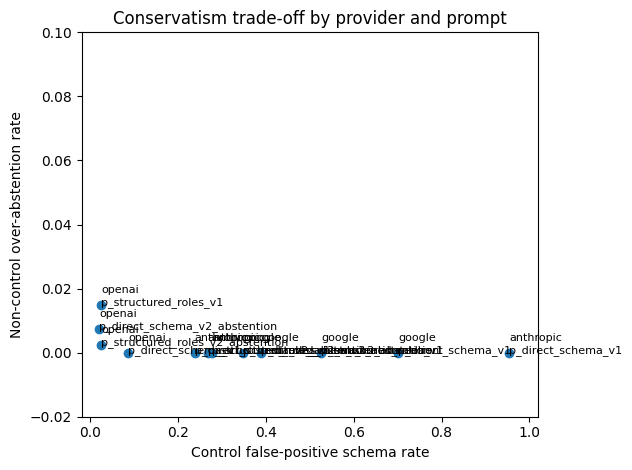

In [6]:
# Plot: control false positives vs non-control over-abstention.
plot_df = provider_prompt.dropna(subset=["control_false_positive_rate", "non_control_over_abstention_rate"]).copy()
if not plot_df.empty:
    fig, ax = plt.subplots()
    ax.scatter(plot_df["control_false_positive_rate"], plot_df["non_control_over_abstention_rate"])
    for _, row in plot_df.iterrows():
        label = f"{row['provider']}\n{row['prompt_id']}"
        ax.annotate(label, (row["control_false_positive_rate"], row["non_control_over_abstention_rate"]), fontsize=8)
    ax.set_title("Conservatism trade-off by provider and prompt")
    ax.set_xlabel("Control false-positive schema rate")
    ax.set_ylabel("Non-control over-abstention rate")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, max(0.1, plot_df["non_control_over_abstention_rate"].max() + 0.05))
    plt.tight_layout()
    plt.show()

In [7]:
# Which provider is the outlier on each sentence?
# A provider is an outlier when it predicts NONE/control while others do not, or vice versa.
key_cols = ["prompt_id", "condition_id", "sentence_id", "repetition_index"]

outlier_rows = []
for keys, g in provider_data.groupby(key_cols, dropna=False):
    if g["provider"].nunique() < 2:
        continue
    none_votes = g.set_index("provider")["predicted_none_control"].to_dict()
    if len(set(none_votes.values())) <= 1:
        continue
    for _, row in g.iterrows():
        others = [v for p, v in none_votes.items() if p != row["provider"]]
        if others and row["predicted_none_control"] != (sum(others) >= len(others)/2):
            outlier_rows.append({
                **dict(zip(key_cols, keys)),
                "provider": row["provider"],
                "model_id": row["model_id"],
                "sentence_type": row["sentence_type"],
                "expected_schema_primary": row["expected_schema_primary"],
                "main_image_schema": row["main_image_schema"],
                "literal_or_metaphorical": row["literal_or_metaphorical"],
                "schema_present": row["schema_present"],
                "provider_predicted_none": row["predicted_none_control"],
                "other_provider_votes": str(none_votes),
            })

outliers = pd.DataFrame(outlier_rows)
save_csv(outliers, "provider_none_control_outlier_examples.csv")
display(outliers.head(30))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/provider_none_control_outlier_examples.csv


,prompt_id,condition_id,sentence_id,repetition_index,provider,model_id,sentence_type,expected_schema_primary,main_image_schema,literal_or_metaphorical,schema_present,provider_predicted_none,other_provider_votes
0,p_direct_schema_v1,c_temp_03_v1,s0024,0,openai,openai_gpt_5_4_mini,control_weak_schema,NONE,NONE,control,no,True,"{'openai': True, 'anthropic': False, 'google':..."
1,p_direct_schema_v1,c_temp_03_v1,s0024,0,anthropic,claude_sonnet_4_6,control_weak_schema,NONE,CONTAINER,metaphorical,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
2,p_direct_schema_v1,c_temp_03_v1,s0024,0,google,gemini_2_5_flash,control_weak_schema,NONE,CONTAINER,literal,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
3,p_direct_schema_v1,c_temp_03_v1,s0024,1,anthropic,claude_sonnet_4_6,control_weak_schema,NONE,CONTAINER,metaphorical,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
4,p_direct_schema_v1,c_temp_03_v1,s0025,0,openai,openai_gpt_5_4_mini,control_weak_schema,NONE,NONE,control,no,True,"{'openai': True, 'anthropic': False, 'google':..."
5,p_direct_schema_v1,c_temp_03_v1,s0025,0,anthropic,claude_sonnet_4_6,control_weak_schema,NONE,CONTAINER,metaphorical,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
6,p_direct_schema_v1,c_temp_03_v1,s0025,0,google,gemini_2_5_flash,control_weak_schema,NONE,SOURCE_PATH_GOAL,literal,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
7,p_direct_schema_v1,c_temp_03_v1,s0025,1,openai,openai_gpt_5_4_mini,control_weak_schema,NONE,NONE,control,no,True,"{'openai': True, 'anthropic': False, 'google':..."
8,p_direct_schema_v1,c_temp_03_v1,s0025,1,anthropic,claude_sonnet_4_6,control_weak_schema,NONE,CONTAINER,metaphorical,yes,False,"{'openai': True, 'anthropic': False, 'google':..."
9,p_direct_schema_v1,c_temp_03_v1,s0025,1,google,gemini_2_5_flash,control_weak_schema,NONE,CONTAINER,literal,yes,False,"{'openai': True, 'anthropic': False, 'google':..."


In [8]:
# Provider behaviour by sentence type and prompt generation.
provider_sentence = (
    provider_data.groupby(["provider", "model_id", "prompt_generation", "sentence_type"])
    .agg(
        n=("run_key", "count"),
        none_prediction_rate=("predicted_none_control", "mean"),
        primary_schema_accuracy=("primary_schema_correct", "mean"),
        lm_accuracy=("lm_correct", "mean"),
        control_false_positive_rate=("substantive_schema_on_control", "mean"),
        non_control_over_abstention_rate=("over_abstained_on_non_control", "mean"),
    )
    .reset_index()
)

save_csv(provider_sentence, "provider_sentence_type_conservatism.csv")
display(display_percent_table(provider_sentence, [
    "none_prediction_rate", "primary_schema_accuracy", "lm_accuracy",
    "control_false_positive_rate", "non_control_over_abstention_rate"
]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/provider_sentence_type_conservatism.csv


,provider,model_id,prompt_generation,sentence_type,n,none_prediction_rate,primary_schema_accuracy,lm_accuracy,control_false_positive_rate,non_control_over_abstention_rate
0,anthropic,claude_sonnet_4_6,v1,control_weak_schema,396,38.9%,38.9%,38.9%,61.1%,0.0%
1,anthropic,claude_sonnet_4_6,v1,literal_spatial,402,0.0%,79.6%,100.0%,0.0%,0.0%
2,anthropic,claude_sonnet_4_6,v1,metaphorical_spatial,402,0.0%,93.5%,100.0%,0.0%,0.0%
3,anthropic,claude_sonnet_4_6,v2_abstention,control_weak_schema,396,74.2%,74.2%,74.2%,25.8%,0.0%
4,anthropic,claude_sonnet_4_6,v2_abstention,literal_spatial,402,0.0%,81.3%,99.3%,0.0%,0.0%
5,anthropic,claude_sonnet_4_6,v2_abstention,metaphorical_spatial,402,0.0%,95.0%,100.0%,0.0%,0.0%
6,google,gemini_2_5_flash,v1,control_weak_schema,396,38.6%,38.6%,38.6%,61.4%,0.0%
7,google,gemini_2_5_flash,v1,literal_spatial,402,0.0%,83.3%,100.0%,0.0%,0.0%
8,google,gemini_2_5_flash,v1,metaphorical_spatial,402,0.0%,92.5%,100.0%,0.0%,0.0%
9,google,gemini_2_5_flash,v2_abstention,control_weak_schema,396,63.1%,63.1%,63.1%,36.9%,0.0%


## Thesis interpretation prompts

Possible thesis claims:

- A model may achieve high non-control accuracy while still being too liberal in assigning schemas to controls.
- A conservative model may reduce control false positives without necessarily losing non-control performance.
- Provider differences should be interpreted as differences in annotation behaviour, not just raw accuracy.
- If OpenAI shows low control false-positive rates and low non-control over-abstention, it is more calibrated rather than merely conservative.
- If Gemini has high control false-positive rates, this suggests a provider-specific tendency toward schema over-attribution under cognitive-linguistic prompting.